# Implementation of Nulcear Recoil Yield on the WIMP sensitivity curve

## steps:

- 1. Get the diffrential rate of E_nr curve
- 2. translate it to histogram
- 3. get recoil yield curve
- 4. combine 2 & 3, make hist of differential rate of E_ee
- 5. modify the sensitivity code, and extract the curve 

In [22]:
from analysis.rate_models import get_rate_ben
from analysis.dm_params import DMParams
import numpy as np
import analysis.plotter as plotter
import matplotlib.pyplot as plt
import scipy.integrate as integrate

# astro parameters in accordance with recommandation by (arxiv:2105.00599)
params = DMParams(m_D_GeV = 5,
                 sigma_pb = 0.1,
                 exposure_kgdays = 11,
                 E_th_KeV= 0.63
                 )

## 1. diffrential Nuclear Recoil rate by Ben's formula

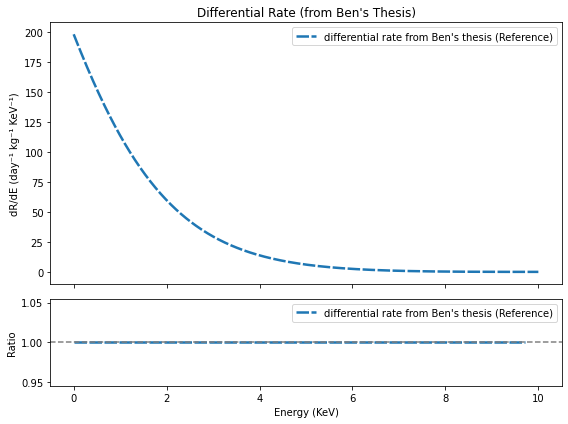

316.80360790683176

In [23]:
E_Rs_KeV = np.linspace(0.0001, 10, 1000)
dRs0 = [get_rate_ben(E, params) for E in E_Rs_KeV]
fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0], ref_index = 0, 
                               labels=["differential rate from Ben's thesis"], panel_type= "ratio")
axes[0].set_title("Differential Rate (from Ben's Thesis)")
plt.show()

integrate.quad(lambda E: get_rate_ben(E, dm_params = params), 0, 10)[0]

## 2. translate it from continuous function to histogram"

In [24]:
E_min, E_max = 0, 10   # Example range
bin_width = 0.05
bin_edges = np.arange(E_min, E_max + bin_width, bin_width)

In [25]:
hist_counts = []
for i in range(len(bin_edges)-1):
    val, _ = integrate.quad(lambda E: get_rate_ben(E, dm_params = params), bin_edges[i], bin_edges[i+1])
    hist_counts.append(val)
hist_counts = np.array(hist_counts)

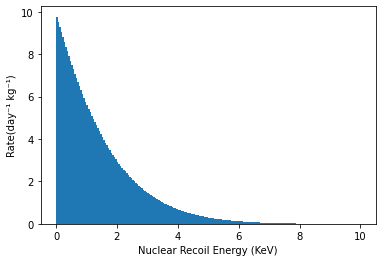

316.80360741504927

In [ ]:
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.bar(bin_centers, hist_counts, width=bin_width, align='center')
plt.xlabel("Nuclear Recoil Energy (KeV)")
plt.ylabel("Rate(day⁻¹ kg⁻¹)")
plt.show()

print('total rate: ', np.sum(hist_counts))


## 3. get recoil yield curve
use E_nr vs. E_ee plot

In [ ]:
from yield_functions import yield1, lindhard, damicm_fit, damicm_no_fano, damicm_fano

## 4. combine 2 & 3, make hist of differential rate of E_ee


total rate:  316.7046843791842


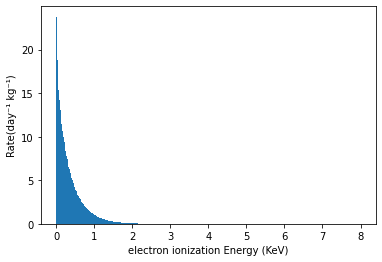

In [94]:
E_nr_min, E_nr_max = 0.001, 30.0     # keVnr (example)
dE_nr = 0.001                       # fine recoil step for smooth remapping
E_nr = np.arange(E_nr_min, E_nr_max + dE_nr, dE_nr)

# Compute weights (expected counts per small recoil bin)
weights = get_rate_ben(E_nr,params) * dE_nr

# Map to ionized (measured) energy
E_ion = lindhard(E_nr)   

# hist of E_ee
Eion_min, Eion_max = 0, 8
Eion_width = 0.02
Eion_edges = np.arange(Eion_min, Eion_max + Eion_width, Eion_width)
hist_Eion, _ = np.histogram(E_ion, bins=Eion_edges, weights=weights)
print('total rate: ', np.sum(hist_Eion))

Eion_centers = 0.5 * (Eion_edges[1:] + Eion_edges[:-1])
plt.bar(Eion_centers, hist_Eion, width=Eion_width, align='center')
plt.xlabel("electron ionization Energy (KeV)")
plt.ylabel("Rate(day⁻¹ kg⁻¹)")
plt.show()